### Equipo 4
**Integrantes:**
- Cristóbal Castro L.
- Tomás Cortés B.
- Sebastián Padilla C.

**Fuentes:**
- [Habitable Exoplanets Catalog - ESI](https://phl.upr.edu/projects/earth-similarity-index-esi)
- [Rodríguez-Mozos & Moya (2017) - SEPHI](https://academic.oup.com/mnras/article/471/4/4628/4096396)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dataset
df_raw = pd.read_csv("hwc.csv")

print(f"Dims: {df_raw.shape}")
df_raw.head()

Dims: (5599, 118)


,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
0,OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00,-120.0,413.0,0,Mass,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
1,Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60,-3.6,4.4,0,Mass,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
2,Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10,NaN,NaN,0,M-R relationship,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
3,K2-283 b,Transit,K2,2018,2019-09-05,12.20,NaN,NaN,0,M-R relationship,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
4,Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94,NaN,NaN,0,M-R relationship,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre


In [ ]:
# sobre la temperatura: prioridad a superficie, si no, equilibrio
df_raw["TEMP_CALC_F"] = df_raw["P_TEMP_SURF"].fillna(df_raw["P_TEMP_EQUIL"])

# variables índices (radio, densidad, velocidad de escape, y temperatura)
cols_vars = ["P_NAME", "P_RADIUS", "P_DENSITY", "P_ESCAPE", "TEMP_CALC_F"]

# filtro nans
df = df_raw.dropna(subset=cols_vars).copy()

# post-filtro
original = len(df_raw)
filtrados = len(df)
print(f"planetas supervivientes: {filtrados} ({ (filtrados/original)*100:.2f}%)")

planetas supervivientes: 5358 (95.70%)


In [ ]:
# referencias tierra y pesos ESI
ref_esi = {
    "P_RADIUS": (1.0, 0.57),
    "P_DENSITY": (1.0, 1.07),
    "P_ESCAPE": (1.0, 0.70),
    "TEMP_CALC_F": (288.0, 5.58)
}

def calc_esi(val, x0, w):
    return (1 - np.abs((val - x0) / (val + x0))) ** w

# ESI calculado
df["ESI_CALC"] = (
    calc_esi(df["P_RADIUS"], *ref_esi["P_RADIUS"]) *
    calc_esi(df["P_DENSITY"], *ref_esi["P_DENSITY"]) *
    calc_esi(df["P_ESCAPE"], *ref_esi["P_ESCAPE"]) *
    calc_esi(df["TEMP_CALC_F"], *ref_esi["TEMP_CALC_F"])
)

# SEPHI
df["L1_Telluric"] = np.where((df["P_RADIUS"] <= 1.5) & (df["P_DENSITY"] >= 0.5), 1.0, 0.01)

def calc_L2(ve): # atmos/gravedad
    if ve <= 0 or ve >= 8.66: return 0.01
    return ve if ve <= 1 else max(0.01, 1.0 - ((ve - 1) / 7.66)**2)

def calc_L3(t): # agua líquida
    if t < 273 or t > 373: return 0.01
    return max(0.01, 1.0 - abs(t - 288) / 85.0)

df["L2_Atmos"] = df["P_ESCAPE"].apply(calc_L2)
df["L3_Water"] = df["TEMP_CALC_F"].apply(calc_L3)
df["L4_Mag"] = 0.5 # por falta de datos magnéticos

# SEPHI calculado
df["SEPHI_CALC"] = (df["L1_Telluric"] * df["L2_Atmos"] * df["L3_Water"] * df["L4_Mag"]) ** 0.25

In [ ]:
# top 10 según SEPHI
cols_res = ["P_NAME", "ESI_CALC", "P_ESI", "SEPHI_CALC", "P_RADIUS", "TEMP_CALC_F"]
df_top10 = df[cols_res].sort_values(by="SEPHI_CALC", ascending=False).head(10)

df_top10

,P_NAME,ESI_CALC,P_ESI,SEPHI_CALC,P_RADIUS,TEMP_CALC_F
934,Teegarden's Star b,0.921347,0.968362,0.828005,1.050,293.09014
537,TOI-700 d,0.848478,0.941176,0.812073,1.073,276.93926
1291,Kepler-1649 c,0.832094,0.925298,0.801817,1.060,302.72840
4849,K2-72 e,0.689688,0.870824,0.789975,1.290,306.68539
762,LP 890-9 c,0.069703,0.885251,0.781482,1.367,280.87679
3728,GJ 1061 c,0.694004,0.857911,0.778538,1.180,310.49580
480,TOI-700 e,0.786202,0.912032,0.778248,0.953,305.68811
3183,K2-3 d,0.521035,0.814264,0.762634,1.458,315.44273
3509,Ross 128 b,0.700688,0.857721,0.758751,1.110,316.64171
2239,TRAPPIST-1 d,0.662330,0.907662,0.751635,0.788,295.67425


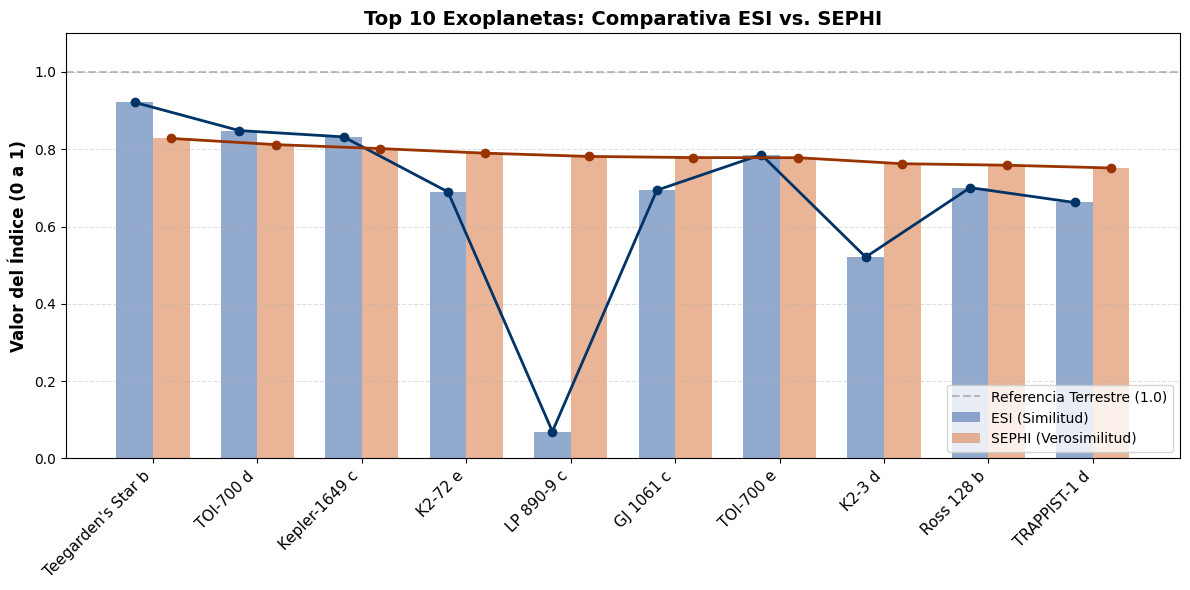

In [ ]:
# gráfico 1
nombres = df_top10["P_NAME"]
esi_vals = df_top10["ESI_CALC"]
sephi_vals = df_top10["SEPHI_CALC"]

x = np.arange(len(nombres))
width = 0.35

fig1, ax1 = plt.subplots(figsize=(12, 6))

# barras
ax1.bar(x - width/2, esi_vals, width, label="ESI (Similitud)", color="#4C72B0", alpha=0.6)
ax1.bar(x + width/2, sephi_vals, width, label="SEPHI (Verosimilitud)", color="#DD8452", alpha=0.6)

# lineas
ax1.plot(x - width/2, esi_vals, marker="o", color="#003366", linestyle="-", linewidth=2, markersize=6)
ax1.plot(x + width/2, sephi_vals, marker="o", color="#993300", linestyle="-", linewidth=2, markersize=6)

# etiquetas
ax1.set_ylabel("Valor del Índice (0 a 1)", fontsize=12, fontweight="bold")
ax1.set_title("Top 10 Exoplanetas: Comparativa ESI vs. SEPHI", fontsize=14, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(nombres, rotation=45, ha="right", fontsize=11)
ax1.set_ylim(0, 1.1)

# margen terrestre
ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="Referencia Terrestre (1.0)")

ax1.legend(loc="lower right")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

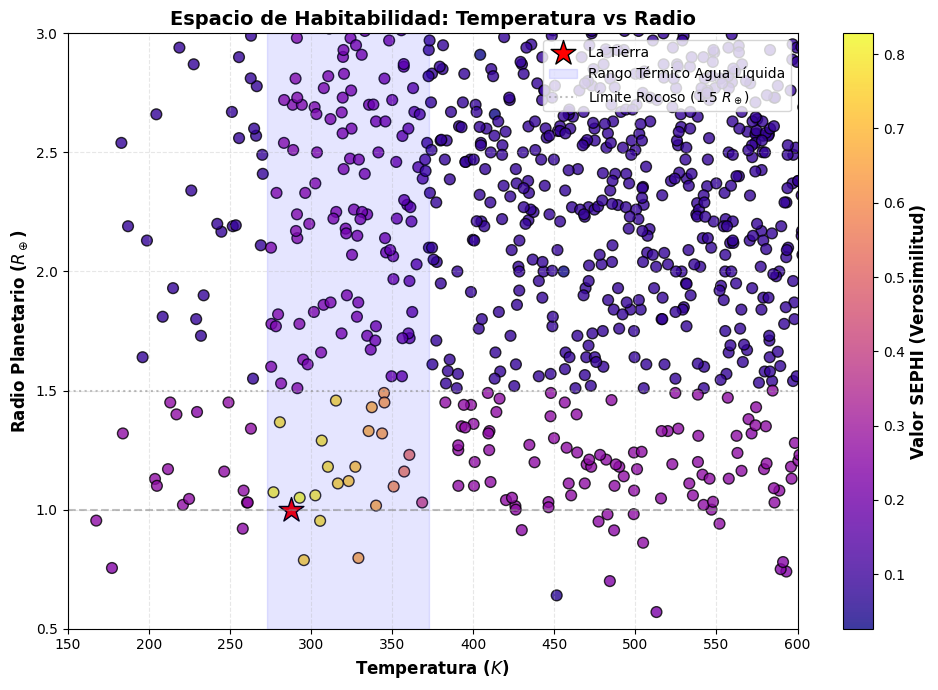

In [ ]:
# gráfico 2
fig2, ax2 = plt.subplots(figsize=(10, 7))

# dispersión
scatter = ax2.scatter(df["TEMP_CALC_F"], df["P_RADIUS"],
                      c=df["SEPHI_CALC"], cmap="plasma",
                      alpha=0.8, edgecolor="black", s=60)

# cb
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label("Valor SEPHI (Verosimilitud)", fontsize=12, fontweight="bold")

# refs
ax2.scatter([288.0], [1.0], color="red", marker="*", s=350, edgecolor="black", label="La Tierra")
ax2.axvspan(273, 373, color="blue", alpha=0.1, label="Rango Térmico Agua Líquida")
ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax2.axhline(1.5, color="gray", linestyle=":", alpha=0.5, label="Límite Rocoso (1.5 $R_\\oplus$)")

# etiquetas
ax2.set_xlabel("Temperatura ($K$)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Radio Planetario ($R_\\oplus$)", fontsize=12, fontweight="bold")
ax2.set_title("Espacio de Habitabilidad: Temperatura vs Radio", fontsize=14, fontweight="bold")

ax2.set_xlim(150, 600)
ax2.set_ylim(0.5, 3.0)

ax2.legend(loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

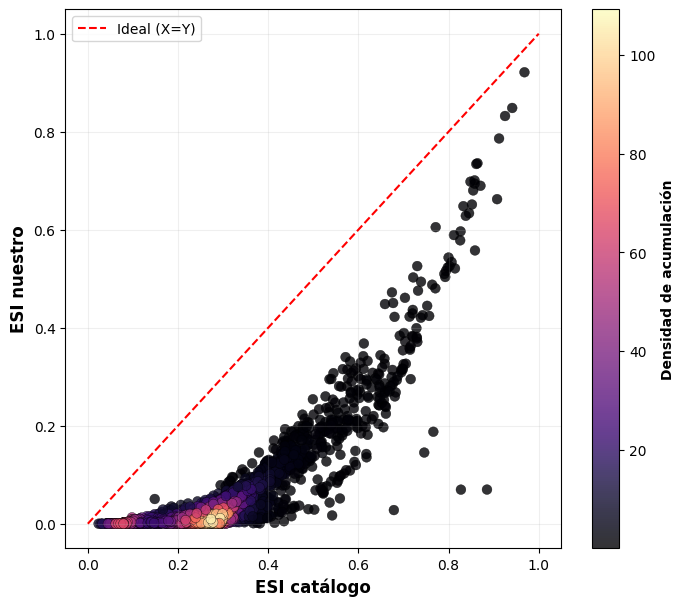

In [ ]:
# ESI nuestro vs ESI dataset
from scipy.stats import gaussian_kde

x = df["P_ESI"]
y = df["ESI_CALC"]
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(8, 7))
sc = plt.scatter(x, y, c=z, s=50, alpha=0.8, cmap="magma", edgecolor="black", linewidth=0.3)
plt.plot([0, 1], [0, 1], "r--", label="Ideal (X=Y)")

cbar = plt.colorbar(sc)
cbar.set_label("Densidad de acumulación", fontweight="bold")

plt.xlabel("ESI catálogo", fontsize=12, fontweight="bold")
plt.ylabel("ESI nuestro", fontsize=12, fontweight="bold")

plt.legend()
plt.grid(True, alpha=0.2)
plt.show()